# 原型：纯 LightGBM 用户侧日前出清电价预测
---
**定位**：在完整 WT-LGBM 方案之前，用最简架构快速验证思路可行性。

**运行方式**：顺序执行所有 Cell 即可。

**依赖**：`lightgbm pandas numpy matplotlib seaborn scikit-learn`

In [1]:
# ============================================================
# Cell 1: 导入 & 全局配置
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ====== 修改这里的参数来调整原型行为 ======
START_DATE  = '2024-01-01'
END_DATE    = '2025-06-30'
FREQ        = '1h'        # '1h'=24点/天, '15min'=96点/天
TEST_DAYS   = 30          # 测试集天数
SEED        = 42
POINTS_PER_DAY = 24 if FREQ == '1h' else 96

np.random.seed(SEED)
print(f'数据: {START_DATE} ~ {END_DATE} | 粒度: {FREQ} | 测试: {TEST_DAYS}天')

数据: 2024-01-01 ~ 2025-06-30 | 粒度: 1h | 测试: 30天


样本数: 13104 | 列数: 8
日期: 2024-01-01 00:00:00 ~ 2025-06-29 23:00:00
电价: 均值=359, std=160, 范围=[50, 686] 元/MWh


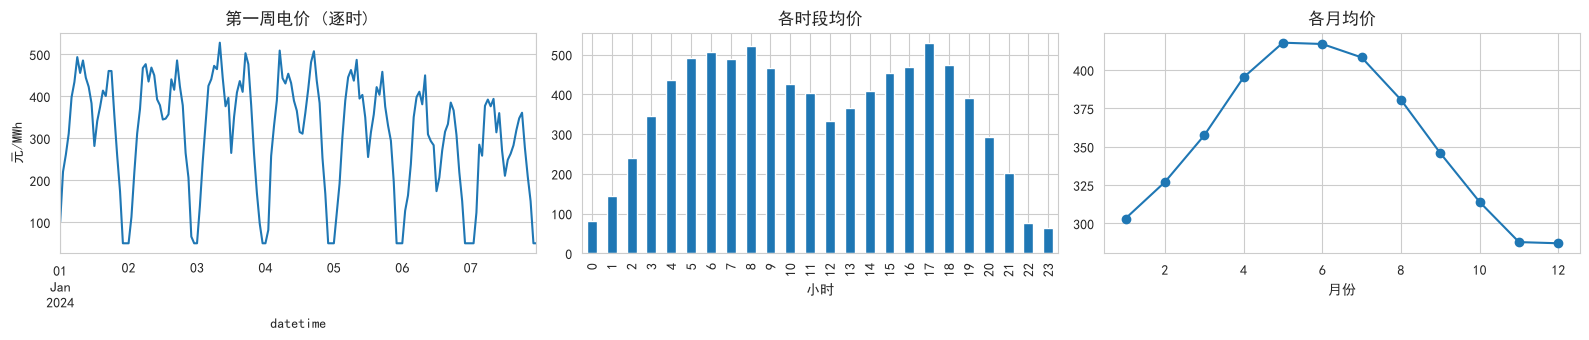

In [2]:
# ============================================================
# Cell 2: Mock 数据生成
# ============================================================
def generate_mock_data(start_date, end_date, freq='1h', seed=42):
    """
    生成带因果关系的模拟电力市场数据。
    电价 = 350 + 150×负荷因子 - 100×新能源渗透率 + 80×峰段 + 50×季节 + 噪声
    """
    rng = np.random.default_rng(seed)
    timestamps = pd.date_range(start_date, end_date, freq=freq, inclusive='left')
    n = len(timestamps)
    hours = timestamps.hour.astype(float)
    months = timestamps.month.astype(float)
    weekdays = timestamps.weekday.astype(float)
    
    def smooth(series, window=None):
        if window is None:
            window = POINTS_PER_DAY // 4
        return pd.Series(series).rolling(window, center=True, min_periods=1).mean().values
    
    # 系统负荷：双峰日曲线 + 周末效应 + 季节
    hour_rad = 2 * np.pi * hours / 24
    daily_shape = 0.65 + 0.15*np.sin(hour_rad - np.pi/3) + 0.20*np.sin(2*hour_rad - np.pi/4)
    load_base = 50000
    weekend_factor = np.where(weekdays >= 5, 0.90, 1.00)
    season_factor = 1.0 + 0.08 * np.sin(2*np.pi*(months-1)/12 - np.pi/2)
    load = load_base * daily_shape * weekend_factor * season_factor
    load += rng.normal(0, load_base * 0.03, n)
    load = smooth(load)
    
    # 风电：随机游走 + 冬季风大
    wind_season = 1.0 + 0.3 * np.sin(2*np.pi*(months-1)/12)
    wind_daily = 1.0 + 0.05 * np.sin(hour_rad)
    wind_random = np.cumsum(rng.normal(0, 0.03, n))
    wind_random = (wind_random - wind_random.mean()) / wind_random.std() * 0.15
    wind = 8000 * wind_season * wind_daily * (1 + wind_random)
    wind = np.clip(smooth(wind), 0, None)
    
    # 光伏：强日周期，夜间归零
    solar_envelope = np.maximum(0, np.sin(np.pi*(hours-6)/12))
    solar_envelope = np.where((hours >= 6) & (hours <= 18), solar_envelope, 0)
    solar_season = 1.0 + 0.4 * np.sin(2*np.pi*(months-5)/12)
    solar = 6000 * solar_envelope * solar_season * (1 + rng.normal(0, 0.2, n))
    solar = np.clip(smooth(solar), 0, None)
    
    # 受电 / 煤电 / 燃机 / 储能
    import_power = smooth(10000 + rng.normal(0, 500, n))
    coal = smooth(np.clip(20000 + 0.25*(load-load_base) + rng.normal(0, 800, n), 5000, None))
    peak_mask = ((hours >= 8) & (hours <= 11)) | ((hours >= 17) & (hours <= 21))
    gas = smooth(np.clip(5000 + peak_mask.astype(float)*3000 + rng.normal(0, 400, n), 0, None))
    valley_mask = (hours >= 0) & (hours <= 6)
    storage = np.where(valley_mask, -1500.0, np.where(peak_mask, 1500.0, 200.0))
    storage = smooth(storage + rng.normal(0, 300, n))
    
    # ★ 目标变量：用户侧日前出清电价
    renewable_pen = (wind + solar) / (load + 1)
    price = (350
             + 150 * (load - load.mean()) / load.std()
             - 100 * renewable_pen
             + 80  * peak_mask.astype(float)
             + 50  * np.sin(2*np.pi*(months-1)/12)
             + rng.normal(0, 25, n))
    price = np.clip(price, 50, 800)
    
    df = pd.DataFrame({
        'datetime': timestamps,
        'sys_load_pred': load, 'wind_power_pred': wind,
        'solar_power_pred': solar, 'power_import': import_power,
        'coal_gen': coal, 'gas_gen': gas, 'storage_plan': storage,
        'user_price': price,
    }).set_index('datetime')
    return df


df = generate_mock_data(START_DATE, END_DATE, FREQ, SEED)

print(f'样本数: {len(df)} | 列数: {len(df.columns)}')
print(f'日期: {df.index[0]} ~ {df.index[-1]}')
print(f'电价: 均值={df.user_price.mean():.0f}, std={df.user_price.std():.0f}, '
      f'范围=[{df.user_price.min():.0f}, {df.user_price.max():.0f}] 元/MWh')

# 快速预览
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
df.user_price.head(24*7).plot(ax=axes[0], title='第一周电价 (逐时)')
axes[0].set_ylabel('元/MWh')
df.groupby(df.index.hour)['user_price'].mean().plot.bar(ax=axes[1], title='各时段均价')
axes[1].set_xlabel('小时')
df.groupby(df.index.month)['user_price'].mean().plot(ax=axes[2], marker='o', title='各月均价')
axes[2].set_xlabel('月份')
plt.tight_layout(); plt.show()

findfont: Failed to find font weight bold, now using 400.


特征维度: 17 | 有效样本: 12936
特征列表: ['sys_load_pred', 'wind_power_pred', 'solar_power_pred', 'power_import', 'coal_gen', 'gas_gen', 'net_load', 'renewable_penetration', 'import_ratio', 'thermal_ratio', 'price_lag_1d', 'price_lag_7d', 'price_ma_24h', 'hour', 'weekday', 'is_weekend', 'month']


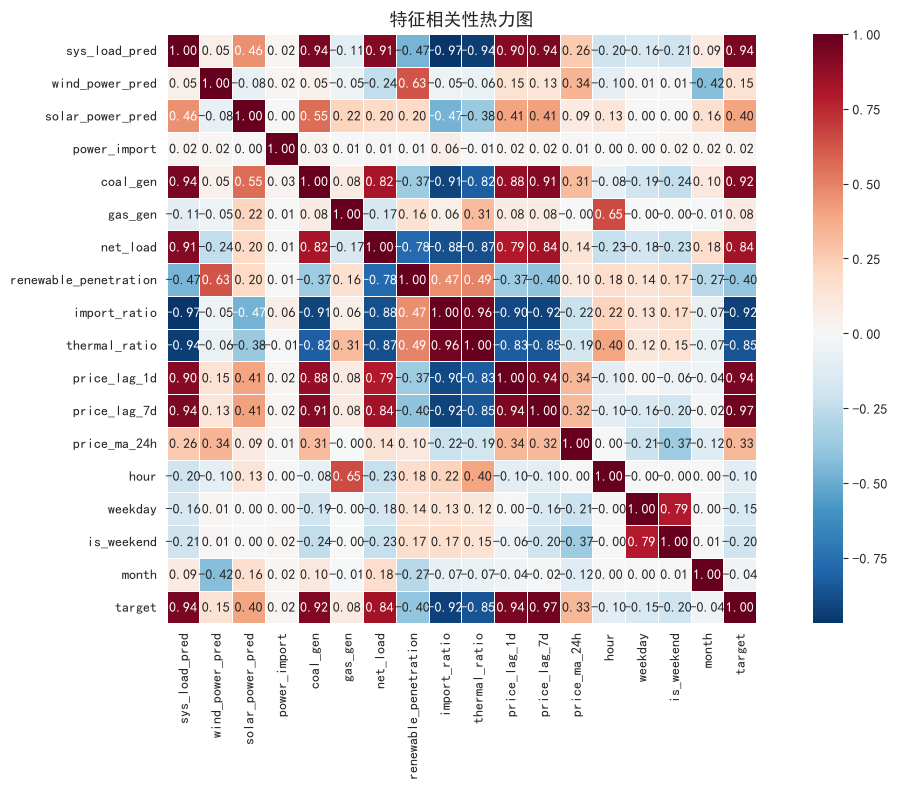

In [3]:
# ============================================================
# Cell 3: 特征工程
# ============================================================
def build_features(df):
    """构建 17 维精简特征集"""
    f = pd.DataFrame(index=df.index)
    ppd = POINTS_PER_DAY
    
    # 直接特征 (6)
    f['sys_load_pred']    = df['sys_load_pred']
    f['wind_power_pred']  = df['wind_power_pred']
    f['solar_power_pred'] = df['solar_power_pred']
    f['power_import']     = df['power_import']
    f['coal_gen']         = df['coal_gen']
    f['gas_gen']          = df['gas_gen']
    
    # 构造特征 (4)
    f['net_load']              = df['sys_load_pred'] - df['wind_power_pred'] - df['solar_power_pred']
    f['renewable_penetration'] = (df['wind_power_pred']+df['solar_power_pred']) / (df['sys_load_pred']+1)
    f['import_ratio']          = df['power_import'] / (df['sys_load_pred']+1)
    f['thermal_ratio']         = (df['coal_gen']+df['gas_gen']) / (df['sys_load_pred']+1)
    
    # 滞后特征 (3)
    price = df['user_price']
    f['price_lag_1d']  = price.shift(ppd)
    f['price_lag_7d']  = price.shift(7*ppd)
    f['price_ma_24h']  = price.shift(1).rolling(ppd, min_periods=1).mean()
    
    # 日期特征 (4)
    f['hour']       = df.index.hour
    f['weekday']    = df.index.weekday
    f['is_weekend'] = (df.index.weekday >= 5).astype(int)
    f['month']      = df.index.month
    
    feature_names = list(f.columns)
    target = df['user_price'].values
    mask = ~f.isna().any(axis=1)
    return f[mask].values, target[mask], f[mask].index, feature_names


X, y, timestamps, feature_names = build_features(df)
print(f'特征维度: {X.shape[1]} | 有效样本: {X.shape[0]}')
print(f'特征列表: {feature_names}')

# 相关性热力图
corr_df = pd.DataFrame(X, columns=feature_names)
corr_df['target'] = y
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('特征相关性热力图', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [4]:
# ============================================================
# Cell 4: 时序分割
# ============================================================
split_idx = len(X) - TEST_DAYS * POINTS_PER_DAY
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
t_train, t_test = timestamps[:split_idx], timestamps[split_idx:]

print(f'训练集: {len(X_train)} ({t_train[0]} ~ {t_train[-1]})')
print(f'测试集: {len(X_test)} ({t_test[0]} ~ {t_test[-1]})')

训练集: 12216 (2024-01-08 00:00:00 ~ 2025-05-30 23:00:00)
测试集: 720 (2025-05-31 00:00:00 ~ 2025-06-29 23:00:00)


In [5]:
# ============================================================
# Cell 5: 训练 LightGBM
# ============================================================
params = {
    'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
    'learning_rate': 0.05, 'num_leaves': 63, 'max_depth': 10,
    'min_data_in_leaf': 20, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 5,
    'lambda_l1': 0.01, 'lambda_l2': 0.01, 'verbosity': -1, 'seed': SEED,
}

train_data = lgb.Dataset(X_train, label=y_train, feature_name=feature_names)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data, feature_name=feature_names)

model = lgb.train(
    params=params, train_set=train_data, valid_sets=[valid_data],
    valid_names=['valid'], num_boost_round=2000,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=100)],
)

y_pred = model.predict(X_test)
print(f'\nBest iteration: {model.best_iteration}')
print(f'Best valid RMSE: {model.best_score["valid"]["rmse"]:.2f}')

[100]	valid's rmse: 26.9763
[200]	valid's rmse: 26.2577

Best iteration: 189
Best valid RMSE: 26.23


In [6]:
# ============================================================
# Cell 6: 评估
# ============================================================
def evaluate(y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mask  = np.abs(y_true) > 1
    mape  = np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask])) * 100
    r2    = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100
    return {'MAE (元/MWh)': round(mae,2), 'RMSE (元/MWh)': round(rmse,2),
            'MAPE (%)': round(mape,2), 'R²': round(r2,4),
            '方向准确率 (%)': round(dir_acc,2)}

metrics = evaluate(y_test, y_pred)
for k, v in metrics.items():
    print(f'  {k}: {v}')

ok = metrics['MAPE (%)'] < 15 and metrics['方向准确率 (%)'] > 60
print(f'\n{"✅ 验收通过" if ok else "⚠️ 需优化"}  |  MAPE<15% & 方向准确率>60%')

  MAE (元/MWh): 20.83
  RMSE (元/MWh): 26.23
  MAPE (%): 7.41
  R²: 0.975
  方向准确率 (%): 86.93

✅ 验收通过  |  MAPE<15% & 方向准确率>60%


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


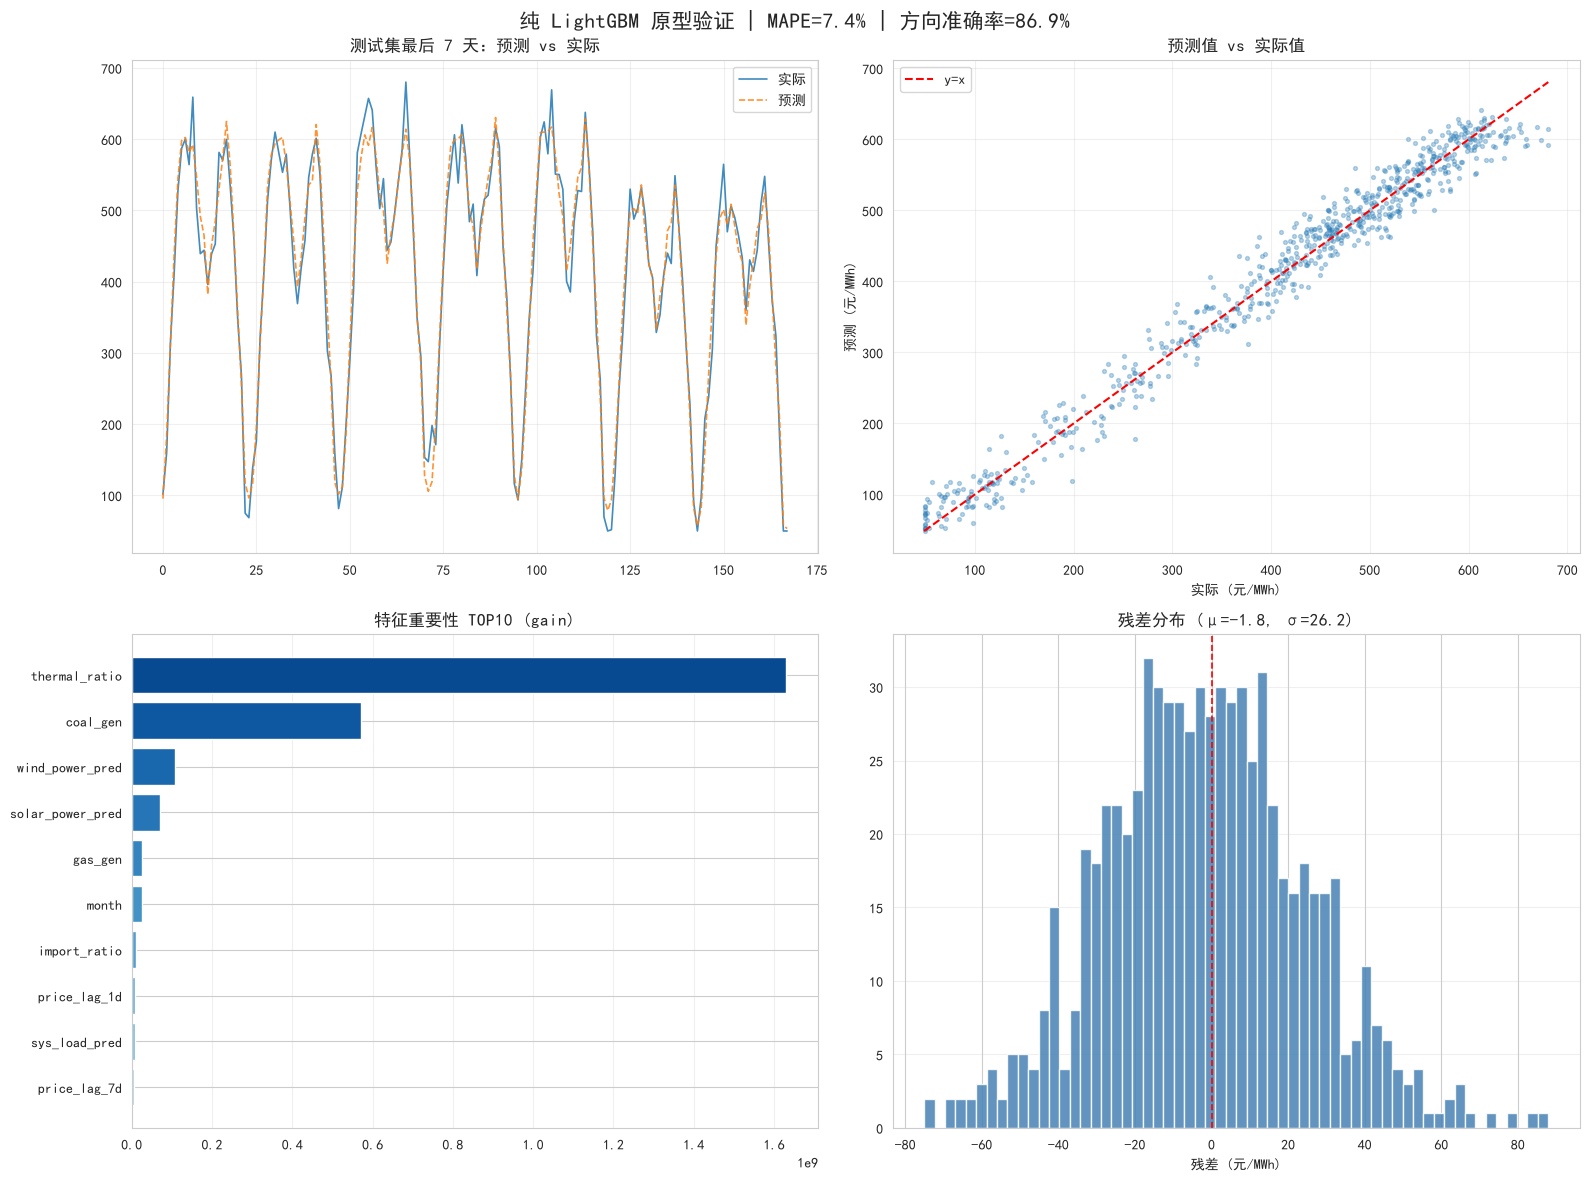

图表已保存: prototype_results.png


In [7]:
# ============================================================
# Cell 7: 可视化（4张子图）
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'纯 LightGBM 原型验证 | MAPE={metrics["MAPE (%)"]:.1f}% | '
             f'方向准确率={metrics["方向准确率 (%)"]:.1f}%',
             fontsize=15, fontweight='bold')

# 子图1: 测试集最后7天预测 vs 实际
ax1 = axes[0,0]
n = 7 * POINTS_PER_DAY
ax1.plot(range(n), y_test[-n:], label='实际', linewidth=1.2, alpha=.85)
ax1.plot(range(n), y_pred[-n:], label='预测', linewidth=1.2, alpha=.85, linestyle='--')
ax1.set_title('测试集最后 7 天：预测 vs 实际', fontsize=12, fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=.3)

# 子图2: 散点图
ax2 = axes[0,1]
ax2.scatter(y_test, y_pred, alpha=.3, s=8)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax2.plot(lims, lims, 'r--', label='y=x')
ax2.set_title('预测值 vs 实际值', fontsize=12, fontweight='bold')
ax2.set_xlabel('实际 (元/MWh)'); ax2.set_ylabel('预测 (元/MWh)')
ax2.legend(); ax2.grid(True, alpha=.3)

# 子图3: 特征重要性 TOP10
ax3 = axes[1,0]
imp = pd.DataFrame({'feature': feature_names,
    'importance': model.feature_importance(importance_type='gain')})
imp = imp.sort_values('importance', ascending=False).head(10)
colors = plt.cm.Blues(np.linspace(.4, .9, len(imp)))
ax3.barh(range(len(imp)), imp['importance'].values, color=colors[::-1])
ax3.set_yticks(range(len(imp)))
ax3.set_yticklabels(imp['feature'].values[::-1])
ax3.set_title('特征重要性 TOP10 (gain)', fontsize=12, fontweight='bold')
ax3.invert_yaxis(); ax3.grid(True, alpha=.3, axis='x')

# 子图4: 残差分布
ax4 = axes[1,1]
res = y_test - y_pred
ax4.hist(res, bins=60, color='steelblue', edgecolor='white', alpha=.85)
ax4.axvline(0, color='red', linestyle='--', linewidth=1.2)
ax4.set_title(f'残差分布 (μ={res.mean():.1f}, σ={res.std():.1f})', fontsize=12, fontweight='bold')
ax4.set_xlabel('残差 (元/MWh)'); ax4.grid(True, alpha=.3, axis='y')

plt.tight_layout()
plt.savefig('prototype_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: prototype_results.png')

In [8]:
# ============================================================
# Cell 8 (可选): 消融实验 — 去掉某类特征看效果
# ============================================================
def train_and_eval(X_tr, y_tr, X_te, y_te, fnames):
    td = lgb.Dataset(X_tr, label=y_tr, feature_name=fnames)
    vd = lgb.Dataset(X_te, label=y_te, reference=td, feature_name=fnames)
    m = lgb.train(params, td, valid_sets=[vd], num_boost_round=2000,
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    p = m.predict(X_te)
    mask = np.abs(y_te) > 1
    mape = np.mean(np.abs((y_te[mask]-p[mask])/y_te[mask])) * 100
    return mape

feature_groups = {
    '全部特征 (17维)':     list(range(17)),
    '去滞后特征 (14维)':   [i for i,n in enumerate(feature_names) if not n.startswith('price_lag') and n != 'price_ma_24h'],
    '去构造特征 (13维)':   [i for i,n in enumerate(feature_names) if n not in ['net_load','renewable_penetration','import_ratio','thermal_ratio']],
    '仅直接+日期 (10维)':  [i for i,n in enumerate(feature_names) if not n.startswith('price_lag') and n != 'price_ma_24h' and n not in ['net_load','renewable_penetration','import_ratio','thermal_ratio']],
}

print(' 特征组                            MAPE')
print('-' * 55)
for name, idx in feature_groups.items():
    mape = train_and_eval(X_train[:, idx], y_train, X_test[:, idx], y_test,
                          [feature_names[i] for i in idx])
    print(f' {name:<30s} {mape:.2f}%')

 特征组                            MAPE
-------------------------------------------------------
 全部特征 (17维)                     7.41%
 去滞后特征 (14维)                    7.31%
 去构造特征 (13维)                    7.22%
 仅直接+日期 (10维)                   7.53%
